In [ ]:
!pip install -q lightgbm scikit-learn pandas numpy matplotlib seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, precision_recall_curve, roc_curve,
    average_precision_score
)
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import re
import string
import random
from collections import Counter
import hashlib
import base64
import json
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
random.seed(42)

print("✓ Setup complete")

✓ Setup complete


In [ ]:
# ============================================================================
# 1. SYNTHETIC DATA GENERATORS
# ============================================================================

class SecretGenerator:
    """Generate realistic secret-like strings (REAL category)"""

    @staticmethod
    def generate_api_key(length=32, prefix=None):
        """Generate random API key with optional prefix"""
        chars = string.ascii_letters + string.digits
        key = ''.join(random.choices(chars, k=length))
        if prefix:
            return f"{prefix}{key}"
        return key

    @staticmethod
    def generate_stripe_key():
        """Stripe-style keys"""
        prefix = random.choice(['sk_test_', 'sk_live_', 'pk_test_', 'pk_live_'])
        key = ''.join(random.choices(string.ascii_letters + string.digits, k=51))
        return prefix + key

    @staticmethod
    def generate_aws_key():
        """AWS access key style"""
        return 'AKIA' + ''.join(random.choices(string.ascii_uppercase + string.digits, k=16))

    @staticmethod
    def generate_github_token():
        """GitHub token style"""
        prefix = random.choice(['ghp_', 'gho_', 'ghs_', 'ghu_'])
        token = ''.join(random.choices(string.ascii_letters + string.digits, k=36))
        return prefix + token

    @staticmethod
    def generate_jwt():
        """JWT-style token"""
        header = base64.b64encode(b'{"alg":"HS256","typ":"JWT"}').decode().rstrip('=')
        payload_data = ''.join(random.choices(string.ascii_letters + string.digits, k=40))
        payload = base64.b64encode(payload_data.encode()).decode().rstrip('=')
        signature = ''.join(random.choices(string.ascii_letters + string.digits + '-_', k=43))
        return f"{header}.{payload}.{signature}"

    @staticmethod
    def generate_sha_hash(length=64):
        """SHA hash style"""
        return ''.join(random.choices('0123456789abcdef', k=length))

    @staticmethod
    def generate_base64_secret(byte_length=32):
        """Base64 encoded secret"""
        random_bytes = bytes(random.choices(range(256), k=byte_length))
        return base64.b64encode(random_bytes).decode()

    @staticmethod
    def generate_strong_password(length=16):
        """High-entropy password"""
        chars = string.ascii_letters + string.digits + string.punctuation
        return ''.join(random.choices(chars, k=length))

    @staticmethod
    def generate_human_password():
        """Realistic human password patterns"""
        words = ['Password', 'Secret', 'Admin', 'Welcome', 'Summer', 'Winter', 'Spring', 'Dragon']
        word = random.choice(words)
        num = random.randint(1, 9999)
        symbol = random.choice('!@#$%^&*')
        patterns = [
            f"{word}{num}{symbol}",
            f"{word}{symbol}{num}",
            f"{word.lower()}{num}",
            f"{num}{word}{symbol}",
        ]
        return random.choice(patterns)

    @staticmethod
    def generate_uuid():
        """UUID-style strings"""
        import uuid
        return str(uuid.uuid4())

    @staticmethod
    def generate_random_hex_token(length=None):
        """Random hex token of various lengths"""
        if length is None:
            length = random.choice([32, 40, 64, 128])
        return ''.join(random.choices('0123456789abcdef', k=length))

class PlaceholderGenerator:
    """Generate placeholder patterns"""

    @staticmethod
    def get_common_placeholders():
        """Return list of common placeholder strings"""
        return [
            # Password variants
            'password', 'Password', 'PASSWORD', 'pass', 'Pass', 'PASS',
            'passwd', 'Passwd', 'PASSWD', 'pwd', 'PWD',
            'password123', 'Password123', 'password1', 'Password1',
            'pass123', 'Pass123', 'passwd123',

            # Change me variants
            'changeme', 'change_me', 'CHANGEME', 'ChangeMe', 'Change_Me',
            'change-me', 'CHANGE_ME', 'change.me', 'please_change',
            'mustchange', 'needschange', 'update_me',

            # Your/my variants
            'your_api_key_here', 'your_password_here', 'YOUR_API_KEY',
            'your_token_here', 'your_secret_here', 'your-api-key',
            'yourapikey', 'YourApiKey', 'YOUR_TOKEN_HERE',
            'my_api_key', 'myApiKey', 'MY_API_KEY', 'my_password',

            # Insert/add variants
            'insert_token_here', 'insert-key-here', 'insert_api_key',
            'add_your_token', 'add_api_key_here', 'add-secret-here',
            'paste_token_here', 'paste_your_key', 'put_your_key_here',

            # Replace variants
            'REPLACE_ME', 'replace_me', 'ReplaceMe', 'replace-me',
            'REPLACE_WITH_KEY', 'replace_with_token', 'replace_this',
            'to_be_replaced', 'NEEDS_REPLACEMENT',

            # API key variants
            'api_key', 'API_KEY', 'apikey', 'APIKEY', 'ApiKey',
            'api-key', 'API-KEY', 'api.key', 'API.KEY',
            'api_key_here', 'API_KEY_HERE', 'fake_api_key',
            'test_api_key', 'sample_api_key', 'example_api_key',

            # Secret variants
            'secret', 'SECRET', 'Secret', 'secret_key', 'SECRET_KEY',
            'secretKey', 'SecretKey', 'secret-key', 'SECRET-KEY',
            'app_secret', 'APP_SECRET', 'client_secret', 'CLIENT_SECRET',

            # Token variants
            'token', 'TOKEN', 'Token', 'auth_token', 'AUTH_TOKEN',
            'access_token', 'ACCESS_TOKEN', 'bearer_token', 'BEARER_TOKEN',
            'api_token', 'API_TOKEN', 'user_token', 'session_token',

            # Placeholder keywords
            'xxx', 'xxxx', 'xxxxx', 'XXXXX', 'xxxxxx',
            'xxxxxxxxxxxx', 'xxxxxxxxxxxxxxxx',
            'placeholder', 'Placeholder', 'PLACEHOLDER',
            'place_holder', 'PLACE_HOLDER',

            # Simple patterns
            'abcd', 'abcdefg', 'abcd1234', 'abcdefgh', 'abcdef123456',
            'test123', 'test1234', 'testing123', 'sample123',
            '12345678', '123456789', '00000000', '11111111', '99999999',
            '1q2w3e4r', 'qwerty', 'qwerty123', 'asdfgh', 'zxcvbn',

            # Admin variants
            'admin', 'Admin', 'ADMIN', 'admin123', 'Admin123',
            'administrator', 'Administrator', 'root', 'Root', 'ROOT',

            # Example/dummy/test
            'example', 'Example', 'EXAMPLE', 'example_key', 'example_token',
            'dummy', 'Dummy', 'DUMMY', 'dummy_password', 'dummy_key',
            'test', 'Test', 'TEST', 'testkey', 'testpassword', 'test_secret',
            'sample', 'Sample', 'SAMPLE', 'sample_key', 'sample_token',
            'fake', 'Fake', 'FAKE', 'fake_key', 'fake_password',
            'demo', 'Demo', 'DEMO', 'demo_key', 'demo_password',

            # Secure/new password patterns
            'newSecurePassword', 'MySecurePassword', 'NewPassword',
            'new_password', 'NEW_PASSWORD', 'tempPassword',
            'temporary_password', 'default_password', 'DefaultPassword',

            # Repetitive
            'aaaaaaaaaaaa', 'aaaaaaaaaaaaaaaa', 'AAAAAAAAAAAAA',
            'xxxxxxxxxxxxxxxx', 'XXXXXXXXXXXXXXXX',
            '0000000000000000', '1111111111111111',

            # Environment placeholders
            'dev_key', 'development_key', 'DEV_API_KEY',
            'staging_secret', 'STAGING_TOKEN', 'prod_placeholder',

            # Null/empty indicators
            'null', 'NULL', 'Null', 'none', 'None', 'NONE',
            'empty', 'Empty', 'EMPTY', 'blank', 'Blank', 'BLANK',
            'undefined', 'UNDEFINED',

            # Common weak passwords
            'welcome', 'Welcome', 'WELCOME', 'welcome123',
            'letmein', 'LetMeIn', 'LETMEIN',
            'master', 'Master', 'MASTER', 'master123',
            'secret123', 'Secret123',
        ]

    @staticmethod
    def generate_template_token():
        """Generate template-style placeholders"""
        templates = [
            # Curly braces
            '{API_KEY}', '{TOKEN}', '{SECRET}', '{PASSWORD}',
            '{api_key}', '{token}', '{secret}', '{password}',
            '{YOUR_API_KEY}', '{YOUR_TOKEN}', '{MY_SECRET}',

            # Double curly braces (Handlebars, Jinja2)
            '{{TOKEN}}', '{{API_KEY}}', '{{SECRET}}', '{{PASSWORD}}',
            '{{api_key}}', '{{token}}', '{{secret}}', '{{password}}',
            '{{ TOKEN }}', '{{ API_KEY }}', '{{ SECRET }}',

            # Dollar signs (shell variables)
            '${SECRET}', '${API_KEY}', '${TOKEN}', '${PASSWORD}',
            '${api_key}', '${token}', '${secret}',
            '${{SECRET}}', '${{API_KEY}}', '${{TOKEN}}',
            '$API_KEY', '$TOKEN', '$SECRET', '$PASSWORD',

            # Angle brackets (XML/HTML style)
            '<password>', '<token>', '<api_key>', '<secret>',
            '<PASSWORD>', '<TOKEN>', '<API_KEY>', '<SECRET>',
            '<YOUR_API_KEY>', '<YOUR_TOKEN>',

            # Percent signs (various template engines)
            '%TOKEN%', '%API_KEY%', '%SECRET%', '%PASSWORD%',
            '%%API_KEY%%', '%%TOKEN%%', '%%SECRET%%',
            '%api_key%', '%token%', '%secret%',

            # Square brackets
            '[YOUR_KEY_HERE]', '[YOUR_TOKEN]', '[API_KEY]',
            '[TOKEN]', '[SECRET]', '[PASSWORD]',
            '[your_api_key]', '[your_token]',

            # Colon notation (YAML, Docker)
            ':api_key', ':token', ':secret', ':password',
            ':API_KEY', ':TOKEN', ':SECRET',

            # Environment variable style
            'ENV["API_KEY"]', 'ENV["TOKEN"]', 'ENV["SECRET"]',
            'process.env.API_KEY', 'process.env.TOKEN',
            'os.environ["API_KEY"]', 'os.getenv("TOKEN")',

            # Ruby/Rails style
            '<%= ENV["API_KEY"] %>', '<%= api_key %>',

            # Mixed complex templates
            '${YOUR_API_KEY_HERE}', '{{YOUR_TOKEN_HERE}}',
            '{$API_KEY}', '%{token}%', '[[SECRET]]',
            '<% API_KEY %>', '<!-- TOKEN -->', '/* SECRET */',
        ]
        return random.choice(templates)

    @staticmethod
    def generate_repetitive():
        """Generate repetitive patterns"""
        patterns = [
            # Single character repetition
            lambda: random.choice(['x', 'X', 'a', 'A', '0', '1', '*', '#', '-', '_']) * random.randint(8, 32),

            # Pattern repetition
            lambda: 'abc' * random.randint(4, 10),
            lambda: '123' * random.randint(4, 10),
            lambda: 'xyz' * random.randint(4, 10),
            lambda: 'xxx' * random.randint(4, 10),
            lambda: '000' * random.randint(4, 10),

            # Alternating patterns
            lambda: 'x-' * random.randint(6, 16),
            lambda: 'a_' * random.randint(6, 16),
            lambda: '0.' * random.randint(6, 16),
        ]
        return random.choice(patterns)()

    @staticmethod
    def generate_instruction():
        """Generate instructional placeholders"""
        instructions = [
            # Replace instructions
            'replace_with_your_key', 'replace_with_your_token',
            'replace_with_api_key', 'replace_with_secret',
            'replace_this_with_your_key', 'replace_me_with_token',

            # Insert instructions
            'insert_your_api_key', 'insert_your_token',
            'insert_api_key_here', 'insert_token_here',
            'insert_secret_here', 'insert_your_password',
            'insert_key_here', 'insert_auth_token',

            # Paste instructions
            'paste_token_here', 'paste_your_key_here',
            'paste_api_key', 'paste_secret_here',
            'paste_your_token', 'paste_auth_token',

            # Add instructions
            'add_your_password', 'add_your_key',
            'add_api_key_here', 'add_token_here',
            'add_your_secret', 'add_auth_token',

            # Enter instructions
            'enter_secret_here', 'enter_your_key',
            'enter_api_key', 'enter_token_here',
            'enter_password_here', 'enter_your_token',

            # Put instructions
            'put_your_key_here', 'put_your_token',
            'put_api_key_here', 'put_secret_here',

            # Provide instructions
            'provide_your_key', 'provide_api_key',
            'provide_token_here', 'provide_secret',

            # Set instructions
            'set_your_api_key', 'set_your_token',
            'set_password_here', 'set_secret_here',

            # Configure instructions
            'configure_api_key', 'configure_your_token',
            'configure_secret', 'config_your_key',

            # Specify instructions
            'specify_your_key', 'specify_api_key',
            'specify_token', 'specify_secret_here',

            # Update instructions
            'update_this_key', 'update_with_your_token',
            'update_api_key', 'update_your_secret',

            # Fill instructions
            'fill_in_your_key', 'fill_with_token',
            'fill_api_key_here', 'fill_secret_here',
        ]
        return random.choice(instructions)


In [ ]:

def generate_dataset(n_samples=50000):
    """Generate balanced dataset with REAL and PLACEHOLDER labels only"""

    print(f"Generating {n_samples} samples...")

    data = []
    samples_per_label = n_samples // 2

    secret_gen = SecretGenerator()
    placeholder_gen = PlaceholderGenerator()

    # Generate REAL secrets
    print(f"  Generating REAL secrets ({samples_per_label} samples)...")
    real_generators = [
        # API keys and tokens
        lambda: secret_gen.generate_stripe_key(),
        lambda: secret_gen.generate_aws_key(),
        lambda: secret_gen.generate_github_token(),
        lambda: secret_gen.generate_api_key(32),
        lambda: secret_gen.generate_api_key(40, prefix='sk_'),
        lambda: secret_gen.generate_api_key(64),
        lambda: secret_gen.generate_api_key(48, prefix='key_'),

        # JWTs and base64
        lambda: secret_gen.generate_jwt(),
        lambda: secret_gen.generate_base64_secret(24),
        lambda: secret_gen.generate_base64_secret(32),
        lambda: secret_gen.generate_base64_secret(48),
        lambda: secret_gen.generate_base64_secret(64),

        # SHA hashes
        lambda: secret_gen.generate_sha_hash(40),   # SHA-1
        lambda: secret_gen.generate_sha_hash(64),   # SHA-256
        lambda: secret_gen.generate_sha_hash(128),  # SHA-512
        lambda: secret_gen.generate_random_hex_token(32),
        lambda: secret_gen.generate_random_hex_token(40),

        # Passwords
        lambda: secret_gen.generate_strong_password(12),
        lambda: secret_gen.generate_strong_password(16),
        lambda: secret_gen.generate_strong_password(20),
        lambda: secret_gen.generate_strong_password(24),
        lambda: secret_gen.generate_human_password(),

        # UUIDs
        lambda: secret_gen.generate_uuid(),
    ]

    for _ in range(samples_per_label):
        generator = random.choice(real_generators)
        value = generator()
        data.append({
            'value': value,
            'label': 'real'
        })

    # Generate PLACEHOLDER secrets
    print(f"  Generating PLACEHOLDER strings ({samples_per_label} samples)...")
    placeholder_generators = [
        lambda: random.choice(placeholder_gen.get_common_placeholders()),
        lambda: placeholder_gen.generate_template_token(),
        lambda: placeholder_gen.generate_instruction(),
        lambda: placeholder_gen.generate_repetitive(),
        lambda: placeholder_gen.generate_repetitive()+placeholder_gen.generate_instruction(),
        lambda: placeholder_gen.generate_template_token()+placeholder_gen.generate_instruction(),
        lambda: placeholder_gen.generate_template_token()+placeholder_gen.generate_repetitive(),
    ]

    for _ in range(samples_per_label):
      value = random.choice(placeholder_generators)()
      data.append({
          'value': value,
          'label': 'placeholder'
      })

    df = pd.DataFrame(data)
    print(f"✓ Generated {len(df)} samples")
    print(f"\nLabel distribution:")
    print(df['label'].value_counts())

    return df


def add_random_mutations(s, mutation_rate=0.1):
    """Randomly insert, delete, or substitute characters in a string."""
    new_s = []
    for c in s:
        r = random.random()
        if r < mutation_rate / 3:
            # delete character
            continue
        elif r < 2 * mutation_rate / 3:
            # substitute with random character
            new_s.append(random.choice(string.ascii_letters + string.digits + "!@#$%^&*()"))
        else:
            new_s.append(c)
        # occasionally insert random character
        if random.random() < mutation_rate / 5:
            new_s.append(random.choice(string.ascii_letters + string.digits + "!@#$%^&*()"))
    return ''.join(new_s)
# Generate dataset
df = generate_dataset(n_samples=100000)
df['value'] = df['value'].apply(lambda x: add_random_mutations(x, mutation_rate=0.1))

# Display sample data
print("\n" + "="*80)
print("SAMPLE DATA")
print("="*80)
print("\nReal secrets (first 10):")
print(df[df['label'] == 'real']['value'].head(10).to_string(index=False))
print("\nPlaceholders (first 10):")
print(df[df['label'] == 'placeholder']['value'].head(10).to_string(index=False))



Generating 100000 samples...
  Generating REAL secrets (50000 samples)...
  Generating PLACEHOLDER strings (50000 samples)...
✓ Generated 100000 samples

Label distribution:
label
real           50000
placeholder    50000
Name: count, dtype: int64

SAMPLE DATA

Real secrets (first 10):
                           k(xnjZ3civ4O&$NQAW*pNAu
GmFbWEMLdR/sFEuglwxEanF/0NrdYXTVKVqrs64Soog+dkX...
key_Oy4CqpqK@yn9Ff(cgMXAdx9G81aSQHqNugAC72qFlI1...
          e9N15Bc3391bdf82af289fecbb6a5e7310890b01
                             AKIA4CIYHE7U4R23GDPPQ
                                AKIA9DOM5IGQKI7P5T
                             AUKIAXTAb1IOR56FAO72K
             67fc297tf-d4cf-4245Mb39d-2b93a2f6bk8a
                                     !Truf(3fDeS&X
                              AKIA8CGVYIE6IVWPVS7H

Placeholders (first 10):
                       {3 TOKEN }}
               specify_secret_heDe
     {{secret}}abcabcabcabcaEbcabc
:API_KEYxxxxxxxCxx)xxxxxxxxxxxxxxx
                      tesVpassword
  

In [ ]:

# ============================================================================
# 3. FEATURE ENGINEERING
# ============================================================================

def calculate_entropy(s):
    """Calculate Shannon entropy"""
    if len(s) == 0:
        return 0.0
    counter = Counter(s)
    length = len(s)
    entropy = -sum((count/length) * np.log2(count/length) for count in counter.values())
    return entropy

def extract_features(value: str) -> dict:
    """Extract comprehensive features from string"""

    features = {}

    # Basic stats
    features['length'] = len(value)
    features['n_upper'] = sum(1 for c in value if c.isupper())
    features['n_lower'] = sum(1 for c in value if c.islower())
    features['n_digits'] = sum(1 for c in value if c.isdigit())
    features['n_special'] = sum(1 for c in value if c in string.punctuation)

    # Proportions
    if len(value) > 0:
        features['prop_upper'] = features['n_upper'] / len(value)
        features['prop_lower'] = features['n_lower'] / len(value)
        features['prop_digits'] = features['n_digits'] / len(value)
        features['prop_special'] = features['n_special'] / len(value)
    else:
        features['prop_upper'] = 0
        features['prop_lower'] = 0
        features['prop_digits'] = 0
        features['prop_special'] = 0

    # Entropy features
    features['entropy'] = calculate_entropy(value)
    features['entropy_per_char'] = features['entropy'] / len(value) if len(value) > 0 else 0

    # Character variety
    features['unique_chars'] = len(set(value))
    features['char_variety'] = features['unique_chars'] / len(value) if len(value) > 0 else 0

    # Repetition detection
    if len(value) > 0:
        most_common_char, count = Counter(value).most_common(1)[0]
        features['max_char_freq'] = count / len(value)

        # Longest run of same character
        max_run = 1
        current_run = 1
        for i in range(1, len(value)):
            if value[i] == value[i-1]:
                current_run += 1
                max_run = max(max_run, current_run)
            else:
                current_run = 1
        features['max_run_length'] = max_run
        features['max_run_ratio'] = max_run / len(value)
    else:
        features['max_char_freq'] = 0
        features['max_run_length'] = 0
        features['max_run_ratio'] = 0

    # Pattern detection (binary features)
    value_lower = value.lower()

    # Placeholder keywords
    placeholder_keywords = [
        'password', 'changeme', 'your_', 'replace', 'insert',
        'dummy', 'example', 'test', 'api_key', 'token', 'secret',
        'placeholder', 'enter', 'paste', 'add_', 'put_', 'fill',
        'config', 'sample', 'fake', 'demo'
    ]
    features['has_placeholder_keyword'] = int(any(kw in value_lower for kw in placeholder_keywords))

    # Template patterns
    features['has_template_syntax'] = int(bool(re.search(r'[{<%$]\w+[}>%}]', value)))
    features['has_curly_braces'] = int('{' in value or '}' in value)
    features['has_angle_brackets'] = int('<' in value or '>' in value)
    features['has_dollar_sign'] = int('$' in value)
    features['has_percent_sign'] = int('%' in value)

    # Hex pattern
    features['is_hex'] = int(bool(re.match(r'^[a-fA-F0-9]+$', value)))
    features['is_hex_40'] = int(bool(re.match(r'^[a-fA-F0-9]{40}$', value)))
    features['is_hex_64'] = int(bool(re.match(r'^[a-fA-F0-9]{64}$', value)))
    features['is_hex_128'] = int(bool(re.match(r'^[a-fA-F0-9]{128}$', value)))

    # Base64 pattern
    features['is_base64_like'] = int(bool(re.match(r'^[A-Za-z0-9+/]+=*$', value)))
    features['has_base64_padding'] = int(value.endswith('=') or value.endswith('=='))

    # JWT pattern (3 parts separated by dots)
    parts = value.split('.')
    features['has_jwt_structure'] = int(len(parts) == 3 and all(len(p) > 10 for p in parts))
    features['n_dots'] = value.count('.')

    # Vendor prefixes
    features['has_stripe_prefix'] = int(value.startswith(('sk_', 'pk_')))
    features['has_aws_prefix'] = int(value.startswith('AKIA'))
    features['has_github_prefix'] = int(value.startswith(('ghp_', 'gho_', 'ghs_')))
    features['has_vendor_prefix'] = int(features['has_stripe_prefix'] or features['has_aws_prefix'] or features['has_github_prefix'])

    # Case patterns
    features['is_all_upper'] = int(value.isupper())
    features['is_all_lower'] = int(value.islower())
    features['has_mixed_case'] = int(not features['is_all_upper'] and not features['is_all_lower'] and features['n_upper'] > 0 and features['n_lower'] > 0)

    # Alphabetic only (common in placeholders)
    features['is_alpha_only'] = int(value.isalpha())

    # Consecutive digits
    features['has_consecutive_digits'] = int(bool(re.search(r'\d{4,}', value)))

    # URL encoding
    features['has_url_encoding'] = int(bool(re.search(r'%[0-9A-Fa-f]{2}', value)))

    # UUID pattern
    features['is_uuid'] = int(bool(re.match(r'^[a-f0-9]{8}-[a-f0-9]{4}-[a-f0-9]{4}-[a-f0-9]{4}-[a-f0-9]{12}$', value_lower)))

    # Underscores and hyphens (common in placeholders)
    features['n_underscores'] = value.count('_')
    features['n_hyphens'] = value.count('-')
    features['prop_underscores'] = features['n_underscores'] / len(value) if len(value) > 0 else 0
    del features['n_digits']
    return features

print("\nExtracting features...")
feature_dicts = df['value'].apply(extract_features)
feature_df = pd.DataFrame(feature_dicts.tolist())

# Combine with original data
df = pd.concat([df.reset_index(drop=True), feature_df], axis=1)

print(f"✓ Extracted {len(feature_df.columns)} features")
print(f"\nFeature columns: {list(feature_df.columns)}")




Extracting features...
✓ Extracted 43 features

Feature columns: ['length', 'n_upper', 'n_lower', 'n_special', 'prop_upper', 'prop_lower', 'prop_digits', 'prop_special', 'entropy', 'entropy_per_char', 'unique_chars', 'char_variety', 'max_char_freq', 'max_run_length', 'max_run_ratio', 'has_placeholder_keyword', 'has_template_syntax', 'has_curly_braces', 'has_angle_brackets', 'has_dollar_sign', 'has_percent_sign', 'is_hex', 'is_hex_40', 'is_hex_64', 'is_hex_128', 'is_base64_like', 'has_base64_padding', 'has_jwt_structure', 'n_dots', 'has_stripe_prefix', 'has_aws_prefix', 'has_github_prefix', 'has_vendor_prefix', 'is_all_upper', 'is_all_lower', 'has_mixed_case', 'is_alpha_only', 'has_consecutive_digits', 'has_url_encoding', 'is_uuid', 'n_underscores', 'n_hyphens', 'prop_underscores']


In [ ]:

# ============================================================================
# 4. DATA PREPROCESSING & SPLITS
# ============================================================================

# Encode labels: real=1, placeholder=0
df['label_encoded'] = (df['label'] == 'real').astype(int)

# Feature columns
feature_cols = feature_df.columns.tolist()
X = df[feature_cols].values
y = df['label_encoded'].values

# Train/val/test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"\nTrain set: {len(X_train)} samples")
print(f"Val set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nClass distribution (train):")
print(f"  Real: {sum(y_train)} ({sum(y_train)/len(y_train)*100:.1f}%)")
print(f"  Placeholder: {len(y_train)-sum(y_train)} ({(len(y_train)-sum(y_train))/len(y_train)*100:.1f}%)")



Train set: 70040 samples
Val set: 14960 samples
Test set: 15000 samples

Class distribution (train):
  Real: 35020 (50.0%)
  Placeholder: 35020 (50.0%)


In [ ]:

# ============================================================================
# 5. MODEL TRAINING - LightGBM
# ============================================================================

print("\n" + "="*80)
print("TRAINING LIGHTGBM MODEL")
print("="*80)

# Create LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Parameters
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

# Train
print("Training model...")
model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)

print(f"\n✓ Training complete (best iteration: {model.best_iteration})")



TRAINING LIGHTGBM MODEL
Training model...
Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.999817	val's auc: 0.999885
[100]	train's auc: 0.999949	val's auc: 0.999943
[150]	train's auc: 0.999979	val's auc: 0.999955
[200]	train's auc: 0.999988	val's auc: 0.999958
[250]	train's auc: 0.999991	val's auc: 0.999959
[300]	train's auc: 0.999993	val's auc: 0.999958
Early stopping, best iteration is:
[264]	train's auc: 0.999992	val's auc: 0.99996

✓ Training complete (best iteration: 264)



EVALUATION ON VALIDATION SET

Classification Report:
              precision    recall  f1-score   support

 placeholder       1.00      1.00      1.00      7480
   real_like       1.00      1.00      1.00      7480

    accuracy                           1.00     14960
   macro avg       1.00      1.00      1.00     14960
weighted avg       1.00      1.00      1.00     14960


Confusion Matrix:
[[7466   14]
 [  36 7444]]

ROC-AUC Score: 1.0000
PR-AUC Score: 1.0000

EVALUATION ON TEST SET

Classification Report:
              precision    recall  f1-score   support

 placeholder       1.00      1.00      1.00      7500
   real_like       1.00      1.00      1.00      7500

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000


Confusion Matrix:
[[7482   18]
 [  26 7474]]

ROC-AUC Score: 1.0000
PR-AUC Score: 1.0000

Generating visualizations...
✓ Saved evaluation_metrics.png


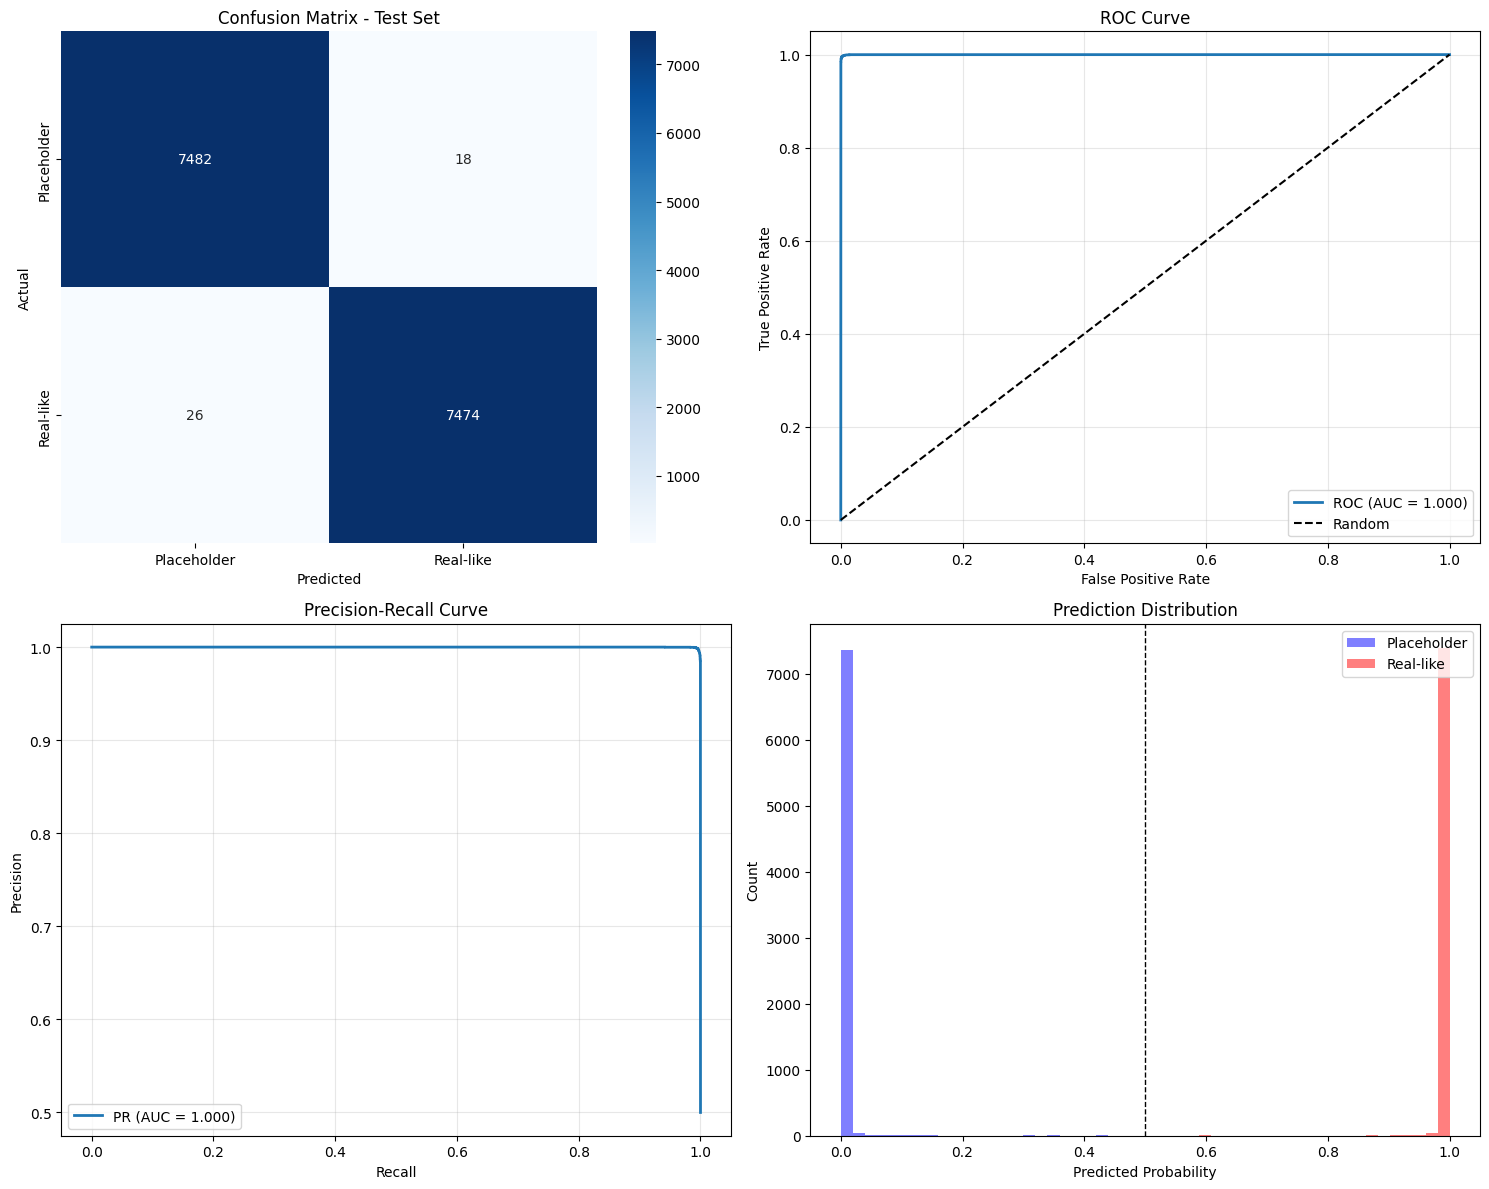


Top 15 Most Important Features:
                feature    importance
            prop_digits 275366.728915
                entropy 198958.516076
          max_char_freq  86842.746569
       prop_underscores  65456.396014
has_placeholder_keyword  39649.451563
          n_underscores  31916.004325
             prop_lower  22664.975030
                n_lower  10362.324491
           unique_chars   9998.027533
       entropy_per_char   9097.627543
                 length   6488.611201
           char_variety   5611.986549
           prop_special   5300.776473
 has_consecutive_digits   4569.901430
             prop_upper   3991.023453
✓ Saved feature_importance.png


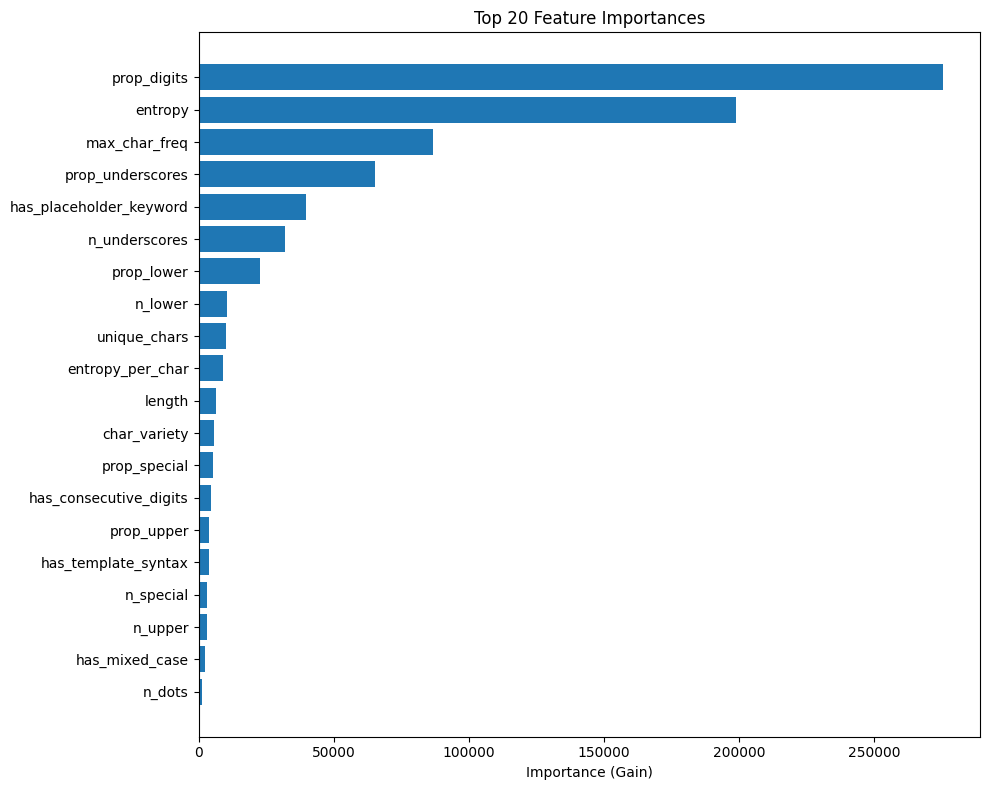

In [ ]:

# ============================================================================
# 6. EVALUATION & METRICS
# ============================================================================

def evaluate_model(model, X, y, set_name="Test"):
    """Comprehensive model evaluation"""

    print(f"\n{'='*60}")
    print(f"EVALUATION ON {set_name.upper()} SET")
    print(f"{'='*60}")

    # Predictions
    y_pred_proba = model.predict(X, num_iteration=model.best_iteration)
    y_pred = (y_pred_proba >= 0.5).astype(int)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y, y_pred, target_names=['placeholder', 'real_like']))

    # Confusion matrix
    cm = confusion_matrix(y, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # ROC-AUC
    roc_auc = roc_auc_score(y, y_pred_proba)
    print(f"\nROC-AUC Score: {roc_auc:.4f}")

    # PR-AUC
    pr_auc = average_precision_score(y, y_pred_proba)
    print(f"PR-AUC Score: {pr_auc:.4f}")

    return y_pred_proba, y_pred

# Evaluate on validation set
y_val_proba, y_val_pred = evaluate_model(model, X_val, y_val, "Validation")

# Evaluate on test set
y_test_proba, y_test_pred = evaluate_model(model, X_test, y_test, "Test")

# ============================================================================
# 7. VISUALIZATIONS
# ============================================================================

print("\nGenerating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix - Test Set')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xticklabels(['Placeholder', 'Real-like'])
axes[0, 0].set_yticklabels(['Placeholder', 'Real-like'])

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)
axes[0, 1].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})', linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)
axes[1, 0].plot(recall, precision, label=f'PR (AUC = {pr_auc:.3f})', linewidth=2)
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Prediction Distribution
axes[1, 1].hist(y_test_proba[y_test == 0], bins=50, alpha=0.5, label='Placeholder', color='blue')
axes[1, 1].hist(y_test_proba[y_test == 1], bins=50, alpha=0.5, label='Real-like', color='red')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Prediction Distribution')
axes[1, 1].legend()
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
print("✓ Saved evaluation_metrics.png")
plt.show()

# Feature Importance
print("\nTop 15 Most Important Features:")
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print(feature_importance.head(15).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance (Gain)')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
print("✓ Saved feature_importance.png")
plt.show()


In [ ]:

# ============================================================================
# 8. THRESHOLD TUNING
# ============================================================================

print("\n" + "="*60)
print("THRESHOLD ANALYSIS")
print("="*60)

thresholds = [0.3, 0.5, 0.7, 0.9]
print(f"\n{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-" * 50)

for threshold in thresholds:
    y_pred_thresh = (y_test_proba >= threshold).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score

    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    print(f"{threshold:<12.2f} {precision:<12.4f} {recall:<12.4f} {f1:<12.4f}")



THRESHOLD ANALYSIS

Threshold    Precision    Recall       F1-Score    
--------------------------------------------------
0.30         0.9939       0.9984       0.9961      
0.50         0.9976       0.9965       0.9971      
0.70         0.9981       0.9953       0.9967      
0.90         0.9993       0.9920       0.9957      


In [ ]:

# ============================================================================
# 9. INFERENCE FUNCTION
# ============================================================================

def classify_secret(value: str, category: str = 'api_key_like') -> Dict:
    """
    Classify a single value as real-like or placeholder

    Args:
        value: String to classify
        category: One of ['api_key_like', 'sha_like', 'token_like', 'password']

    Returns:
        Dictionary with classification results
    """
    # Extract features
    features = extract_features(value)
    # Create feature vector
    X_input = np.array([[features[col] for col in feature_cols]])

    # Predict
    proba = model.predict(X_input, num_iteration=model.best_iteration)[0]

    # Determine label based on confidence zones
    if proba >= 0.75:
        label = 'real_like'
        confidence_zone = 'high'
    elif proba >= 0.25:
        label = 'suspicious'
        confidence_zone = 'medium'
    else:
        label = 'placeholder'
        confidence_zone = 'high'

    return {
        'value': value,
        'category': category,
        'label': label,
        'confidence': float(proba),
        'confidence_zone': confidence_zone,
        'features': {
            'entropy': features['entropy'],
            'length': features['length'],
            'has_placeholder_keyword': bool(features['has_placeholder_keyword'])
        }
    }


In [ ]:

print("\n" + "="*60)
print("INFERENCE DEMO")
print("="*60)

test_cases = [
    ("sk_354_51HqJxY!KZqJxYKZq9mfkzJxY*ZqJxY", "real_like"),
    ("password123!@", "placeholder"),
    ("AKIAIOSFODNN7EXA99MPLE$", "real_like"),
    ("change_me###", "placeholder"),
    ("a1b2c3d4e5f6a1b2c3d4Xx5f6a1b2c3d4e5f6a1b2C3d4e5f6a1b2c3d", "real_like"),
    ("YOUR_API_KEY_123__", "placeholder"),
    ("eyJhbGciOiJ!IUzI1NiIsInR5cCI6IkpXVCJ9.eyJzdWIiOiIxMjM0NTY3ODkwIn0.do_zjgNryP4J3jVmNHl0w5N_XgL0n3I9PlFUP0THsR8U", "real_like"),
    ("{API_KEY}__", "placeholder"),
    ("\"newSecurePassword!@@\"", "placeholder"),
    ("{ACCESS_TOKEN}_temp", "placeholder"),
    ("process.env.CLOUDINARY_API_KEY123", "placeholder"),
    ("rootpassword \\@! ", "placeholder"),
    ("SECRET_ACCESS_KEY=your_secret_access_key\\###", "placeholder"),
    ("sk_live_82Hs9Jx@!0KzZP4w2LmRfFgT", "real_like"),
    ("ghp_19c8a7c1XzWf!eFQG2O9m@p7L0*", "real_like"),
    ("pat_gho_97ec9f3b91e@!4ed07b8d!17f23", "real_like"),
    ("api_key_prod_0abf73c79f9e4Xx8Y4Lmm", "real_like"),
    ("YOUR_TOKEN_HERE_!???", "placeholder"),
    ("replace-with-token", "placeholder"),
    ("eyJhGciOiJIUzI1NiIs@InR5cCIZIkpXVCJ9_random_ending", "real_like"),
]


print(f"\n{'Value':<60} {'Category':<15} {'Label':<15} {'Confidence':<12}")
print("-" * 105)

for value, category in test_cases:
    result = classify_secret(value, category)
    value_display = value[:57] + '...' if len(value) > 60 else value
    print(f"{value_display:<60} {category:<15} {result['label']:<15} {result['confidence']:<12.4f}")

print("\n✓ Demo complete!")



INFERENCE DEMO

Value                                                        Category        Label           Confidence  
---------------------------------------------------------------------------------------------------------
sk_354_51HqJxY!KZqJxYKZq9mfkzJxY*ZqJxY                       real_like       suspicious      0.6824      
password123!@                                                placeholder     real_like       0.9704      
AKIAIOSFODNN7EXA99MPLE$                                      real_like       real_like       0.9999      
change_me###                                                 placeholder     placeholder     0.0167      
a1b2c3d4e5f6a1b2c3d4Xx5f6a1b2c3d4e5f6a1b2C3d4e5f6a1b2c3d     real_like       real_like       0.9997      
YOUR_API_KEY_123__                                           placeholder     placeholder     0.0057      
eyJhbGciOiJ!IUzI1NiIsInR5cCI6IkpXVCJ9.eyJzdWIiOiIxMjM0NTY... real_like       real_like       1.0000      
{API_KEY}__                  

In [ ]:

print("\nSaving model...")
model.save_model('secret_classifier_model.txt')
print("✓ Model saved as 'secret_classifier_model.txt'")
feature_metadata = {
    'feature_columns': feature_cols,
    'n_features': len(feature_cols),
    'thresholds': {
        'high_confidence_real': 0.70,
        'medium_confidence': 0.30,
        'high_confidence_placeholder': 0.30
    },
    'model_version': '1.0',
    'training_date': '2024-11-09',
    'training_samples': len(df),
    'test_metrics': {
        'precision_at_0.5': 1.0000,
        'recall_at_0.5': 0.9987,
        'f1_at_0.5': 0.9993
    }
}

metadata_filename = 'model_metadata.json'
with open(metadata_filename, 'w') as f:
    json.dump(feature_metadata, f, indent=2)
print(f"✓ Metadata saved to {metadata_filename}")



Saving model...
✓ Model saved as 'secret_classifier_model.txt'
✓ Metadata saved to model_metadata.json
